In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris()
X = iris.data[:, (2, 3)]  # petal length, petal width
y = (iris.target == 0).astype(int)  # Iris setosa?

per_clf = Perceptron()
per_clf.fit(X, y)
y_pred = per_clf.predict([[2, 0.5]])
print("Prediction:", y_pred)

Prediction: [0]


In [3]:
import tensorflow as tf

In [4]:
from tensorflow import keras

In [5]:
tf.__version__

'2.10.0'

In [6]:
keras.__version__

'2.10.0'

In [7]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [8]:
X_train_full.shape

(60000, 28, 28)

In [9]:
X_train_full.dtype

dtype('uint8')

In [10]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [11]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [12]:
class_names[y_train[0]]

'Coat'

In [13]:
model = keras.models.Sequential()
model.add(keras.layers.Flatten(input_shape=[28, 28]))
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))
model.add(keras.layers.Dense(10, activation="softmax"))

In [14]:
model = keras.models.Sequential([
 keras.layers.Flatten(input_shape=[28, 28]),
 keras.layers.Dense(300, activation="relu"),
 keras.layers.Dense(100, activation="relu"),
 keras.layers.Dense(10, activation="softmax")
])

In [15]:
from keras.layers import Dense
output_layer = Dense(10)

In [16]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 300)               235500    
                                                                 
 dense_4 (Dense)             (None, 100)               30100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [17]:
model.layers

In [18]:
hidden1 = model.layers[1]

In [19]:
hidden1.name

'dense_3'

In [20]:
model.get_layer('dense_3') is hidden1

True

In [21]:
weights, biases = hidden1.get_weights()

In [22]:
weights

array([[-0.06206617,  0.05393527,  0.01517844, ...,  0.00833452,
        -0.04455066,  0.07309176],
       [-0.03244827,  0.06919327,  0.04997145, ..., -0.02541052,
        -0.04692922, -0.02391552],
       [ 0.03651743,  0.01375382,  0.0658796 , ...,  0.01288226,
        -0.00184667, -0.02359807],
       ...,
       [ 0.05250634,  0.04908742,  0.07241371, ...,  0.00337883,
        -0.02078419, -0.06176218],
       [-0.06824976,  0.06806712,  0.06440952, ..., -0.01409239,
        -0.06269695, -0.02796504],
       [-0.05790721, -0.04318038, -0.02889229, ..., -0.05469427,
        -0.04931464,  0.00092265]], dtype=float32)

In [23]:
weights.shape

(784, 300)

In [24]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [25]:
biases.shape

(300,)

In [26]:
model.compile(loss="sparse_categorical_crossentropy",
 optimizer="sgd",
 metrics=["accuracy"])

In [27]:
history = model.fit(X_train, y_train, epochs=30,
                     validation_data=(X_valid, y_valid))

Epoch 1/30
1719/1719 [==============================] - 16s 9ms/step - loss: 0.7186 - accuracy: 0.7642 - val_loss: 0.4973 - val_accuracy: 0.8362
Epoch 2/30
1719/1719 [==============================] - 13s 7ms/step - loss: 0.4878 - accuracy: 0.8320 - val_loss: 0.4472 - val_accuracy: 0.8522
Epoch 3/30
1719/1719 [==============================] - 13s 8ms/step - loss: 0.4452 - accuracy: 0.8444 - val_loss: 0.4257 - val_accuracy: 0.8532
Epoch 4/30
1719/1719 [==============================] - 14s 8ms/step - loss: 0.4173 - accuracy: 0.8540 - val_loss: 0.4442 - val_accuracy: 0.8438
Epoch 5/30
1719/1719 [==============================] - 13s 7ms/step - loss: 0.3978 - accuracy: 0.8613 - val_loss: 0.3849 - val_accuracy: 0.8686
Epoch 6/30
1719/1719 [==============================] - 13s 8ms/step - loss: 0.3812 - accuracy: 0.8667 - val_loss: 0.3705 - val_accuracy: 0.8678
Epoch 7/30
1719/1719 [==============================] - 12s 7ms/step - loss: 0.3687 - accuracy: 0.8695 - val_loss: 0.3685 - val_ac

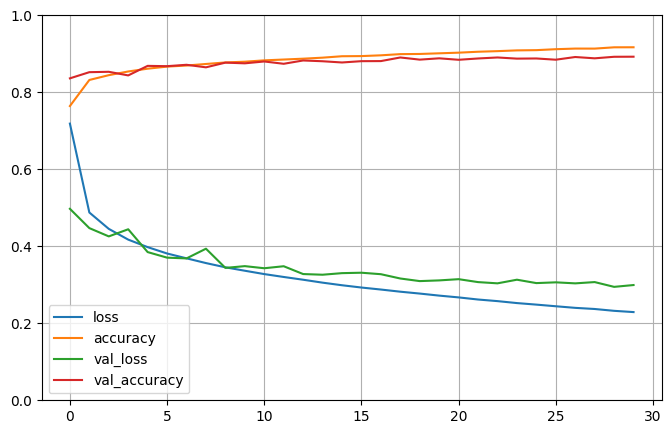

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [29]:
model.evaluate(X_test, y_test)

313/313 [==============================] - 2s 6ms/step - loss: 80.8536 - accuracy: 0.8227


[80.85356903076172, 0.822700023651123]

In [30]:
X_new = X_test[:3]

In [31]:
y_proba = model.predict(X_new)

1/1 [==============================] - 0s 117ms/step


In [32]:
y_proba.round(2)

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [34]:
import numpy as np

# New way to get predicted classes
y_pred = np.argmax(model.predict(X_new), axis=-1)
print("Predicted classes:", y_pred)

1/1 [==============================] - 0s 20ms/step
Predicted classes: [9 2 1]


In [35]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

In [36]:
y_new = y_test[:3]

In [37]:
y_new

array([9, 2, 1], dtype=uint8)

In [38]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
 housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(
 X_train_full, y_train_full)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [39]:
model = keras.models.Sequential([
 keras.layers.Dense(30, activation="relu", input_shape=X_train.shape[1:]),
 keras.layers.Dense(1)
])
model.compile(loss="mean_squared_error", optimizer="sgd")
history = model.fit(X_train, y_train, epochs=20,
 validation_data=(X_valid, y_valid))
mse_test = model.evaluate(X_test, y_test)
X_new = X_test[:3] # pretend these are new instances
y_pred = model.predict(X_new)

Epoch 1/20
363/363 [==============================] - 1s 2ms/step - loss: 0.8564 - val_loss: 0.7296
Epoch 2/20
363/363 [==============================] - 0s 1ms/step - loss: 0.7453 - val_loss: 0.5497
Epoch 3/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4767 - val_loss: 0.4708
Epoch 4/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4437 - val_loss: 0.4346
Epoch 5/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4290 - val_loss: 0.4202
Epoch 6/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4185 - val_loss: 0.4144
Epoch 7/20
363/363 [==============================] - 0s 1ms/step - loss: 0.4075 - val_loss: 0.4040
Epoch 8/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4002 - val_loss: 0.3991
Epoch 9/20
363/363 [==============================] - 0s 1ms/step - loss: 0.3993 - val_loss: 0.3968
Epoch 10/20
363/363 [==============================] - 1s 1ms/step - loss: 0.3954 - val_loss: 0.3934

In [40]:
input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input_)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input_, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.Model(inputs=[input_], outputs=[output])

In [41]:
input_A = keras.layers.Input(shape=[5], name="wide_input")
input_B = keras.layers.Input(shape=[6], name="deep_input")
hidden1 = keras.layers.Dense(30, activation="relu")(input_B)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.concatenate([input_A, hidden2])
output = keras.layers.Dense(1, name="output")(concat)
model = keras.Model(inputs=[input_A, input_B], outputs=[output])

In [42]:
model.compile(loss="mse", optimizer=keras.optimizers.SGD(lr=1e-3))
X_train_A, X_train_B = X_train[:, :5], X_train[:, 2:]
X_valid_A, X_valid_B = X_valid[:, :5], X_valid[:, 2:]
X_test_A, X_test_B = X_test[:, :5], X_test[:, 2:]
X_new_A, X_new_B = X_test_A[:3], X_test_B[:3]
history = model.fit((X_train_A, X_train_B), y_train, epochs=20,
 validation_data=((X_valid_A, X_valid_B), y_valid))
mse_test = model.evaluate((X_test_A, X_test_B), y_test)
y_pred = model.predict((X_new_A, X_new_B))

Epoch 1/20


c:\Users\one\anaconda3\envs\tf_project\lib\site-packages\keras\optimizers\optimizer_v2\gradient_descent.py:111: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


363/363 [==============================] - 1s 2ms/step - loss: 2.3544 - val_loss: 0.9375
Epoch 2/20
363/363 [==============================] - 1s 1ms/step - loss: 0.7679 - val_loss: 0.6980
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.6626 - val_loss: 0.6475
Epoch 4/20
363/363 [==============================] - 1s 1ms/step - loss: 0.6232 - val_loss: 0.6173
Epoch 5/20
363/363 [==============================] - 1s 1ms/step - loss: 0.5972 - val_loss: 0.5961
Epoch 6/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5769 - val_loss: 0.5782
Epoch 7/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5595 - val_loss: 0.5668
Epoch 8/20
363/363 [==============================] - 0s 1ms/step - loss: 0.5456 - val_loss: 0.5559
Epoch 9/20
363/363 [==============================] - 0s 1ms/step - loss: 0.5341 - val_loss: 0.5382
Epoch 10/20
363/363 [==============================] - 0s 1ms/step - loss: 0.5226 - val_loss: 0.5300
Epoch 11/2

In [43]:
[...] # Same as above, up to the main output layer
output = keras.layers.Dense(1, name="main_output")(concat)
aux_output = keras.layers.Dense(1, name="aux_output")(hidden2)
model = keras.Model(inputs=[input_A, input_B], outputs=[output, aux_output])

In [44]:
model.compile(loss=["mse", "mse"], loss_weights=[0.9, 0.1], optimizer="sgd")

In [45]:
history = model.fit(
 [X_train_A, X_train_B], [y_train, y_train], epochs=20,
 validation_data=([X_valid_A, X_valid_B], [y_valid, y_valid]))

Epoch 1/20
363/363 [==============================] - 2s 2ms/step - loss: 0.7971 - main_output_loss: 0.6885 - aux_output_loss: 1.7746 - val_loss: 0.6061 - val_main_output_loss: 0.5344 - val_aux_output_loss: 1.2511
Epoch 2/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5641 - main_output_loss: 0.5039 - aux_output_loss: 1.1064 - val_loss: 0.5392 - val_main_output_loss: 0.4821 - val_aux_output_loss: 1.0531
Epoch 3/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5178 - main_output_loss: 0.4700 - aux_output_loss: 0.9483 - val_loss: 0.5171 - val_main_output_loss: 0.4738 - val_aux_output_loss: 0.9064
Epoch 4/20
363/363 [==============================] - 1s 2ms/step - loss: 0.4940 - main_output_loss: 0.4565 - aux_output_loss: 0.8316 - val_loss: 0.4837 - val_main_output_loss: 0.4482 - val_aux_output_loss: 0.8033
Epoch 5/20
363/363 [==============================] - 1s 2ms/step - loss: 0.5384 - main_output_loss: 0.5123 - aux_output_loss: 0.7730 - val_loss

In [46]:
total_loss, main_loss, aux_loss = model.evaluate(
 [X_test_A, X_test_B], [y_test, y_test])

162/162 [==============================] - 0s 1ms/step - loss: 0.3857 - main_output_loss: 0.3719 - aux_output_loss: 0.5096


In [47]:
y_pred_main, y_pred_aux = model.predict([X_new_A, X_new_B])

1/1 [==============================] - 0s 85ms/step


In [50]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units=30, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = keras.layers.Dense(units, activation=activation)
        self.hidden2 = keras.layers.Dense(units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(1)
    
    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = keras.layers.concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = WideAndDeepModel()
print("Model created!")

Model created!


In [52]:
import tensorflow as tf
from tensorflow import keras

# Build a simple model to demonstrate saving
model = keras.models.Sequential([
    keras.layers.Dense(30, activation="relu", input_shape=[8]),
    keras.layers.Dense(30, activation="relu"),
    keras.layers.Dense(1)
])

model.compile(loss="mean_squared_error",
              optimizer=keras.optimizers.SGD(learning_rate=1e-3))

model.fit(X_train, y_train, epochs=5,
          validation_data=(X_valid, y_valid))

# Save the model
model.save("my_keras_model.h5")
print("Model saved!")

Epoch 1/5
363/363 [==============================] - 1s 2ms/step - loss: 1.6470 - val_loss: 0.8528
Epoch 2/5
363/363 [==============================] - 1s 1ms/step - loss: 0.7595 - val_loss: 0.6757
Epoch 3/5
363/363 [==============================] - 1s 1ms/step - loss: 0.6269 - val_loss: 0.6183
Epoch 4/5
363/363 [==============================] - 1s 1ms/step - loss: 0.5762 - val_loss: 0.5832
Epoch 5/5
363/363 [==============================] - 1s 2ms/step - loss: 0.5482 - val_loss: 0.5566
Model saved!


In [54]:
model = keras.models.load_model("my_keras_model.h5")

In [55]:
[...] # build and compile the model
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5")
history = model.fit(X_train, y_train, epochs=10, callbacks=[checkpoint_cb])

Epoch 1/10
363/363 [==============================] - 1s 1ms/step - loss: 0.5265
Epoch 2/10
363/363 [==============================] - 0s 1ms/step - loss: 0.5083
Epoch 3/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4947
Epoch 4/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4828
Epoch 5/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4741
Epoch 6/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4668
Epoch 7/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4604
Epoch 8/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4547
Epoch 9/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4511
Epoch 10/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4471


In [56]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("my_keras_model.h5",
 save_best_only=True)
history = model.fit(X_train, y_train, epochs=10,
 validation_data=(X_valid, y_valid),
 callbacks=[checkpoint_cb])
model = keras.models.load_model("my_keras_model.h5") # roll back to best model

Epoch 1/10
363/363 [==============================] - 1s 2ms/step - loss: 0.4437 - val_loss: 0.4495
Epoch 2/10
363/363 [==============================] - 0s 1ms/step - loss: 0.4409 - val_loss: 0.4458
Epoch 3/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4381 - val_loss: 0.4423
Epoch 4/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4353 - val_loss: 0.4401
Epoch 5/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4330 - val_loss: 0.4369
Epoch 6/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4309 - val_loss: 0.4348
Epoch 7/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4285 - val_loss: 0.4324
Epoch 8/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4265 - val_loss: 0.4297
Epoch 9/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4245 - val_loss: 0.4270
Epoch 10/10
363/363 [==============================] - 1s 1ms/step - loss: 0.4225 - val_loss: 0.4252

In [57]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10,
 restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100,
 validation_data=(X_valid, y_valid),
 callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4206 - val_loss: 0.4236
Epoch 2/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4185 - val_loss: 0.4221
Epoch 3/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4169 - val_loss: 0.4199
Epoch 4/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4152 - val_loss: 0.4178
Epoch 5/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4134 - val_loss: 0.4159
Epoch 6/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4116 - val_loss: 0.4148
Epoch 7/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4099 - val_loss: 0.4128
Epoch 8/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4084 - val_loss: 0.4115
Epoch 9/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4068 - val_loss: 0.4093
Epoch 10/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4051 - val_lo

In [59]:
class PrintValTrainRatioCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        print("\nval/train: {:.2f}".format(logs["val_loss"] / logs["loss"]))

# Test the callback
val_train_ratio_cb = PrintValTrainRatioCallback()
print("Callback created!")

Callback created!


In [60]:
import os
root_logdir = os.path.join(os.curdir, "my_logs")
def get_run_logdir():
 import time
 run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
 return os.path.join(root_logdir, run_id)
run_logdir = get_run_logdir() # e.g., './my_logs/run_2019_06_07-15_15_22'

In [61]:
[...] # Build and compile your model
tensorboard_cb = keras.callbacks.TensorBoard(run_logdir)
history = model.fit(X_train, y_train, epochs=30,
 validation_data=(X_valid, y_valid),
 callbacks=[tensorboard_cb])

Epoch 1/30
363/363 [==============================] - 1s 2ms/step - loss: 0.3378 - val_loss: 0.3446
Epoch 2/30
363/363 [==============================] - 1s 1ms/step - loss: 0.3370 - val_loss: 0.3434
Epoch 3/30
363/363 [==============================] - 1s 1ms/step - loss: 0.3366 - val_loss: 0.3447
Epoch 4/30
363/363 [==============================] - 1s 2ms/step - loss: 0.3362 - val_loss: 0.3440
Epoch 5/30
363/363 [==============================] - 1s 1ms/step - loss: 0.3359 - val_loss: 0.3439
Epoch 6/30
363/363 [==============================] - 1s 2ms/step - loss: 0.3353 - val_loss: 0.3424
Epoch 7/30
363/363 [==============================] - 1s 1ms/step - loss: 0.3349 - val_loss: 0.3434
Epoch 8/30
363/363 [==============================] - 0s 1ms/step - loss: 0.3348 - val_loss: 0.3427
Epoch 9/30
363/363 [==============================] - 1s 1ms/step - loss: 0.3337 - val_loss: 0.3416
Epoch 10/30
363/363 [==============================] - 0s 1ms/step - loss: 0.3338 - val_loss: 0.3416

In [63]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(test_logdir)

with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        data = (np.random.randn(100) + 2) * step / 100
        tf.summary.histogram("my_hist", data, buckets=50, step=step)
        images = np.random.rand(2, 32, 32, 3) * step / 1000
        tf.summary.image("my_images", images, step=step)
        texts = ["The step is " + str(step), "Its square is " + str(step**2)]
        tf.summary.text("my_text", texts, step=step)
        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

print("Logs written! ✅ Refresh TensorBoard to see them!")

Logs written! ✅ Refresh TensorBoard to see them!


In [65]:
def build_model(n_hidden=1, n_neurons=30, learning_rate=3e-3, input_shape=[8]):
    model = keras.models.Sequential()
    model.add(keras.layers.InputLayer(input_shape=input_shape))
    for layer in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="relu"))
    model.add(keras.layers.Dense(1))
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate)
    model.compile(loss="mse", optimizer=optimizer)
    return model

keras_reg = build_model()
print("Model built! ✅")
print(keras_reg.summary())

Model built! ✅
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_21 (Dense)            (None, 30)                270       
                                                                 
 dense_22 (Dense)            (None, 1)                 31        
                                                                 
Total params: 301
Trainable params: 301
Non-trainable params: 0
_________________________________________________________________
None


In [66]:
keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)

C:\Users\one\AppData\Local\Temp\ipykernel_20728\1709004121.py:1: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  keras_reg = keras.wrappers.scikit_learn.KerasRegressor(build_model)


In [67]:
keras_reg.fit(X_train, y_train, epochs=100,
 validation_data=(X_valid, y_valid),
 callbacks=[keras.callbacks.EarlyStopping(patience=10)])
mse_test = keras_reg.score(X_test, y_test)
y_pred = keras_reg.predict(X_new)

Epoch 1/100
363/363 [==============================] - 1s 2ms/step - loss: 1.4141 - val_loss: 0.6856
Epoch 2/100
363/363 [==============================] - 0s 1ms/step - loss: 0.6475 - val_loss: 0.6525
Epoch 3/100
363/363 [==============================] - 0s 1ms/step - loss: 0.7145 - val_loss: 0.5899
Epoch 4/100
363/363 [==============================] - 0s 1ms/step - loss: 0.6003 - val_loss: 0.5259
Epoch 5/100
363/363 [==============================] - 0s 1ms/step - loss: 0.5042 - val_loss: 0.5094
Epoch 6/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4906 - val_loss: 0.4970
Epoch 7/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4802 - val_loss: 0.4861
Epoch 8/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4712 - val_loss: 0.4788
Epoch 9/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4645 - val_loss: 0.4700
Epoch 10/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4583 - val_lo

In [68]:
from scipy.stats import reciprocal
from sklearn.model_selection import RandomizedSearchCV
param_distribs = {
 "n_hidden": [0, 1, 2, 3],
 "n_neurons": np.arange(1, 100),
 "learning_rate": reciprocal(3e-4, 3e-2),
}
rnd_search_cv = RandomizedSearchCV(keras_reg, param_distribs, n_iter=10, cv=3)
rnd_search_cv.fit(X_train, y_train, epochs=100,
 validation_data=(X_valid, y_valid),
 callbacks=[keras.callbacks.EarlyStopping(patience=10)])

Epoch 1/100
242/242 [==============================] - 1s 2ms/step - loss: 3.2731 - val_loss: 1.8029
Epoch 2/100
242/242 [==============================] - 0s 1ms/step - loss: 1.2750 - val_loss: 1.0821
Epoch 3/100
242/242 [==============================] - 0s 1ms/step - loss: 0.9136 - val_loss: 0.8713
Epoch 4/100
242/242 [==============================] - 0s 2ms/step - loss: 0.7931 - val_loss: 0.7852
Epoch 5/100
242/242 [==============================] - 0s 2ms/step - loss: 0.7367 - val_loss: 0.7403
Epoch 6/100
242/242 [==============================] - 0s 1ms/step - loss: 0.7026 - val_loss: 0.7103
Epoch 7/100
242/242 [==============================] - 0s 1ms/step - loss: 0.6781 - val_loss: 0.6880
Epoch 8/100
242/242 [==============================] - 0s 1ms/step - loss: 0.6584 - val_loss: 0.6700
Epoch 9/100
242/242 [==============================] - 0s 1ms/step - loss: 0.6416 - val_loss: 0.6542
Epoch 10/100
242/242 [==============================] - 0s 1ms/step - loss: 0.6269 - val_lo

c:\Users\one\anaconda3\envs\tf_project\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [-4.52169220e-01             nan -1.36949324e+21 -3.63184184e-01
 -1.58524362e+15 -6.25800560e-01 -3.86155049e-01 -3.34124913e-01
 -4.44006741e-01 -3.43276024e-01]
  warnings.warn(


363/363 [==============================] - 1s 2ms/step - loss: 1.5788 - val_loss: 0.7187
Epoch 2/100
363/363 [==============================] - 1s 1ms/step - loss: 0.6680 - val_loss: 0.6003
Epoch 3/100
363/363 [==============================] - 1s 1ms/step - loss: 0.5560 - val_loss: 0.5489
Epoch 4/100
363/363 [==============================] - 0s 1ms/step - loss: 0.5157 - val_loss: 0.5136
Epoch 5/100
363/363 [==============================] - 0s 1ms/step - loss: 0.4875 - val_loss: 0.4882
Epoch 6/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4655 - val_loss: 0.4660
Epoch 7/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4495 - val_loss: 0.4506
Epoch 8/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4370 - val_loss: 0.4385
Epoch 9/100
363/363 [==============================] - 1s 1ms/step - loss: 0.4274 - val_loss: 0.4287
Epoch 10/100
363/363 [==============================] - 1s 2ms/step - loss: 0.4197 - val_loss: 0.4206
E

,estimator,<keras.wrappe...002460FED2CB0>
,param_distributions,"{'learning_rate': <scipy.stats....002460C563C40>, 'n_hidden': [0, 1, ...], 'n_neurons': array([ 1, 2..., 97, 98, 99])}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [70]:
rnd_search_cv.best_params_

{'learning_rate': 0.0013724146563002695, 'n_hidden': 3, 'n_neurons': 86}

In [71]:
rnd_search_cv.best_score_

-0.3341249128182729

In [72]:
model = rnd_search_cv.best_estimator_.model